In [1]:
from functions import *
from firedrake import *
import numpy as np
from IPython.display import display, HTML
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection #need for quad mesh
import gmsh #unstructed mesh
from firedrake.pyplot import triplot #plotting the mesh
import pandas as pd
import logging
opts = {
    "eps_gen_non_hermitian": None,
    "eps_target": 0.95,              # off 1.0, which is a genuine eigenvalue
    "eps_target_magnitude": None,
    "st_type": "sinvert",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    "st_mat_mumps_icntl_14": 500,
    "eps_true_residual": None
}      

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [2]:
def table_eigenvalues(eig_list, N_list, dof_list, h_list, exact_eigs=None, n_eig_show = 10):
    """
    Generates a table of eigenvalues across different solver runs using pandas.
    Only includes up to the top 10 eigenvalues.
    
    Parameters:
    eig_list (list of lists): The computed eigenvalues for each run.
    N_list (list of int): The mesh resolution (num_cells) for each run.
    dof_list (list of int): The number of Degrees of Freedom for each run.
    h_list (list of float): The maximum cell size (h) for each run.
    exact_eigs (list, optional): Exact eigenvalues to compute convergence rates.
    """
    assert len(eig_list) == len(N_list) == len(dof_list) == len(h_list), "Input lists must match in length."
    
    # Cap the maximum number of rows to 10
    max_eigs = min(n_eig_show, max(len(run) for run in eig_list))
    
    # 1. Format the eigenvalues into strings and pad to max_eigs
    data_dict = {}
    for j, eigs in enumerate(eig_list):
        col = []
        # Slice the list to only process the first 10 eigenvalues
        for i, val in enumerate(eigs[:n_eig_show]):
            
            # Format the computed eigenvalue
            if isinstance(val, complex) or np.iscomplexobj(val):
                val_str = f"{np.real(val):.5f} + {np.imag(val):.5f}i"
            else:
                val_str = f"{val:.5f}"
                
            # Compute convergence rate if exact eigenvalues are provided
            rate_str = ""
            if exact_eigs is not None and i < len(exact_eigs) and j > 0:
                exact_val = exact_eigs[i]
                
                # Check if the previous run had an eigenvalue at this index
                if i < len(eig_list[j-1]):
                    prev_val = eig_list[j-1][i]
                    
                    err_curr = abs(val - exact_val)
                    err_prev = abs(prev_val - exact_val)
                    
                    h_curr = h_list[j]
                    h_prev = h_list[j-1]
                    
                    # Prevent division by zero and log of zero errors
                    if h_curr != h_prev and err_curr > 1e-15 and err_prev > 1e-15:
                        # Use h_prev / h_curr to yield a positive rate since h decreases
                        rate = np.log(err_prev / err_curr) / np.log(h_prev / h_curr)
                        rate_str = f" ({rate:.2f})"
                    elif err_curr <= 1e-15:
                        # Reached machine precision / exact match
                        rate_str = " (exact)"
                        
            col.append(val_str + rate_str)
            
        # Pad missing eigenvalues with a dash up to max_eigs
        col += ["-"] * (max_eigs - len(col))
        
        # Create a combined column header for N and DOF
        col_header = f"N={N_list[j]} (DOF={dof_list[j]})"
        data_dict[col_header] = col
        
    # 2. Create the DataFrame
    df = pd.DataFrame(data_dict)

    # Use standard unicode for terminal/Jupyter row indices
    df.index = [f"λ_{i+1}" for i in range(max_eigs)]
    
    return df
    
def run_mesh_sweep(mesh_hierarchy, space_builder, form_builder, bc_builder, wind_func,
                   n_evals=32, solver_opts=None, drop_harmonic=False, **kwargs):
    """
    Iterates over a list or hierarchy of meshes, assembling and solving the eigenvalue 
    problem for each, and recording the computed eigenvalues and degrees of freedom.
    
    Parameters:
    mesh_hierarchy (list/iterable): A collection of Firedrake Mesh objects (e.g., from MeshHierarchy)
    space_builder (callable): Function to build the FunctionSpace (e.g., FEEC_B_N2_2d1k)
    form_builder (callable): Function to build the bilinear forms (e.g., B_formulation_2d1k)
    bc_builder (callable): Function to generate boundary conditions
    n_evals (int): Number of eigenvalues to compute
    solver_opts (dict): SLEPc/PETSc solver options
    drop_harmonic (bool): Flag to drop harmonic/zero modes from the result
    **kwargs: Additional parameters passed to the builders (e.g., degree=1, u=None, eps=Constant(1.0))
    
    Returns:
    eig_list (list of lists): The eigenvalues computed at each mesh level.
    dof_list (list of ints): The total degrees of freedom at each mesh level.
    N_list (list of ints): The cell counts at each mesh level.
    h_list (list of floats): The maximum cell sizes at each mesh level.
    """
    if solver_opts is None:
        solver_opts = {}

    eig_list = []
    dof_list = []
    N_list = []
    h_list = []  # Explicitly initialized here

    for mesh in mesh_hierarchy:
        u = wind_func(mesh)
        N_list.append(mesh.num_cells())
        
        # Rigorously extract max mesh size h
        V_dg0 = FunctionSpace(mesh, "DG", 0)
        
        # Create an empty Function, then interpolate the symbolic CellSize into it
        h_func = Function(V_dg0).interpolate(CellSize(mesh))
        
        # Now h_func is a computed data object, and we can access the underlying array
        h_max = h_func.dat.data_ro.max() 
        h_list.append(float(h_max)) # Cast to float to ensure it's a standard Python scalar
        
        # 1. Build the Function Space
        # Extract 'degree' from kwargs, default to 1 if not provided
        degree = kwargs.get('degree', 1)
        W = space_builder(mesh, degree=degree)
        
        # 2. Build the Bilinear Forms
        # Extract 'u' and 'eps' from kwargs, providing safe defaults
        eps = kwargs.get('eps', Constant(1.0))
        a, m = form_builder(W, u=u, eps=eps)
        
        # 3. Apply Boundary Conditions
        bcs = bc_builder(W)
        
        # 4. Setup and Solve
        eigenvalue_problem = make_eigensolver(a, m, bcs, n_evals=n_evals, opts=solver_opts)
        eigs, eigfs = solve_eigenpairs(eigenvalue_problem, drop_harmonic=drop_harmonic)
        
        # 5. Store Results
        eig_list.append(eigs)
        dof_list.append(W.dim())
        
    return eig_list, dof_list, N_list, h_list

## FEEC Conforming

In [3]:
import heapq
def generate_maxwell_eigenvalues(n: int) -> list[int]:
  """Generates the first `n` non-zero eigenvalues for the Maxwell

  curl-curl operator on [0, pi]^2 with PEC boundary conditions.

  Parameters:
      n (int): Number of smallest positive eigenvalues to return.

  Returns:
      list[int]: Sorted list of the first n eigenvalues.
  """
  if n <= 0:
    return []

  # Priority queue stores tuples of (lambda_value, m, n)
  # Base modes (1,0) and (0,1) yield lambda = 1
  pq = [(1, 1, 0), (1, 0, 1)]
  visited = {(1, 0), (0, 1)}

  eigenvalues = []

  while len(eigenvalues) < n:
    val, m, n_mode = heapq.heappop(pq)
    eigenvalues.append(val)

    # Explore neighboring modes in the (m, n) lattice
    for dm, dn in [(1, 0), (0, 1)]:
      next_m, next_n = m + dm, n_mode + dn
      if (next_m, next_n) not in visited:
        visited.add((next_m, next_n))
        next_val = next_m**2 + next_n**2
        heapq.heappush(pq, (next_val, next_m, next_n))

  return eigenvalues

def wind0(mesh):
    return None

def get_unstructured_base_mesh(nx, L, filename="unstructured_square.msh"):
    gmsh.initialize()
    try:
        gmsh.option.setNumber("General.Terminal", 0)
        gmsh.model.add("square")
        geo = gmsh.model.geo
        
        lc = L / nx 
        p = [geo.addPoint(x, y, 0, lc) for x, y in [(0, 0), (L, 0), (L, L), (0, L)]]
        lines = [geo.addLine(p[i], p[(i + 1) % 4]) for i in range(4)]
        s = geo.addPlaneSurface([geo.addCurveLoop(lines)])
        geo.synchronize()

        # Firedrake Mapping: 1=Left, 2=Right, 3=Bottom, 4=Top
        # Our lines are generated as: Bottom(0), Right(1), Top(2), Left(3)
        tag_map = {0: 3, 1: 2, 2: 4, 3: 1} 
        
        for i, ln in enumerate(lines):   
            gmsh.model.addPhysicalGroup(1, [ln], tag_map[i])
            
        gmsh.model.addPhysicalGroup(2, [s], 1)
        gmsh.model.mesh.generate(2)
        gmsh.write(filename)
    finally:
        gmsh.finalize()

    return Mesh(filename)


firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


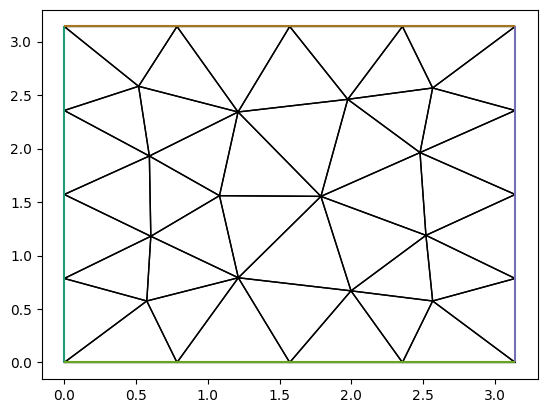

In [6]:
mehs = get_unstructured_base_mesh(4,np.pi, filename="unstructured_square.msh")
triplot(mehs)

In [103]:
N = 4
L = np.pi
num_refinements = 3
true_eigenvalues = generate_maxwell_eigenvalues(30)

base_mesh = SquareMesh(N, N, L, quadrilateral=False, diagonal='crossed')
hierarchy = MeshHierarchy(base_mesh, num_refinements)
    
eigs, dofs, N_list, h_list = run_mesh_sweep(
        mesh_hierarchy=hierarchy,
        space_builder=FEEC_B_N2_2d1k,
        form_builder=B_formulation_2d1k,
        bc_builder=bcs_B_2d1k,
        wind_func = wind0,
        n_evals=100,
        solver_opts=opts,
        drop_harmonic=False,
        degree=1,                                
        eps=Constant(1.0)        
    )


print('B-formulation N2 FEEC Elements crossed mesh')
table_eigenvalues(eigs, N_list, dofs,h_list,true_eigenvalues)

B-formulation N2 FEEC Elements crossed mesh


,N=64 (DOF=353),N=256 (DOF=1345),N=1024 (DOF=5249),N=4096 (DOF=20737)
λ_1,1.01707 + 0.00000i,1.00428 + 0.00000i (2.00),1.00107 + 0.00000i (2.00),1.00027 + 0.00000i (2.00)
λ_2,1.01707 + 0.00000i,1.00428 + 0.00000i (2.00),1.00107 + 0.00000i (2.00),1.00027 + 0.00000i (2.00)
λ_3,2.06860 + 0.00000i,2.01714 + 0.00000i (2.00),2.00428 + 0.00000i (2.00),2.00107 + 0.00000i (2.00)
λ_4,4.26840 + 0.00000i,4.06822 + 0.00000i (1.98),4.01711 + 0.00000i (2.00),4.00428 + 0.00000i (2.00)
λ_5,4.26840 + 0.00000i,4.06822 + 0.00000i (1.98),4.01711 + 0.00000i (2.00),4.00428 + 0.00000i (2.00)
λ_6,5.42218 + 0.00000i,5.10688 + 0.00000i (1.98),5.02676 + 0.00000i (2.00),5.00669 + 0.00000i (2.00)
λ_7,5.42218 + 0.00000i,5.10688 + 0.00000i (1.98),5.02676 + 0.00000i (2.00),5.00669 + 0.00000i (2.00)
λ_8,9.06677 + 0.00000i,8.27397 + 0.00000i (1.96),8.06854 + 0.00000i (2.00),8.01713 + 0.00000i (2.00)
λ_9,10.28932 + 0.00000i,9.34270 + 0.00000i (1.91),9.08649 + 0.00000i (1.99),9.02167 + 0.00000i (2.00)
λ_10,10.28932 + 0.00000i,9.34270 + -0.00000i (1.91),9.08649 + 0.00000i (1.99),9.02167 + -0.00000i (2.00)


In [104]:
N = 4
L = np.pi
num_refinements = 3
true_eigenvalues = generate_maxwell_eigenvalues(30)

base_mesh = SquareMesh(N, N, L, quadrilateral=False, diagonal='crossed')
hierarchy = MeshHierarchy(base_mesh, num_refinements)
    
eigs, dofs, N_list, h_list = run_mesh_sweep(
        mesh_hierarchy=hierarchy,
        space_builder=FEEC_B_N1_2d1k,
        form_builder=B_formulation_2d1k,
        bc_builder=bcs_B_2d1k,
        wind_func = wind0,
        n_evals=30,
        solver_opts=opts,
        drop_harmonic=False,
        degree=1,                                
        eps=Constant(1.0)        
    )


print('B-formulation N1 FEEC Elements unstructued mesh')
table_eigenvalues(eigs, N_list, dofs,h_list,true_eigenvalues)

B-formulation N1 FEEC Elements unstructued mesh


,N=64 (DOF=145),N=256 (DOF=545),N=1024 (DOF=2113),N=4096 (DOF=8321)
λ_1,1.00416 + 0.00000i,1.00106 + 0.00000i (1.97),1.00027 + 0.00000i (1.99),1.00007 + 0.00000i (2.00)
λ_2,1.00416 + 0.00000i,1.00106 + 0.00000i (1.97),1.00027 + 0.00000i (1.99),1.00007 + 0.00000i (2.00)
λ_3,1.96548 + 0.00000i,1.99143 + 0.00000i (2.01),1.99786 + 0.00000i (2.00),1.99946 + 0.00000i (2.00)
λ_4,4.06022 + 0.00000i,4.01672 + 0.00000i (1.85),4.00426 + 0.00000i (1.97),4.00107 + 0.00000i (1.99)
λ_5,4.06022 + 0.00000i,4.01672 + 0.00000i (1.85),4.00426 + 0.00000i (1.97),4.00107 + 0.00000i (1.99)
λ_6,4.89289 + 0.00000i,4.97499 + 0.00000i (2.10),4.99382 + 0.00000i (2.02),4.99846 + 0.00000i (2.00)
λ_7,4.89289 + 0.00000i,4.97499 + 0.00000i (2.10),4.99382 + 0.00000i (2.02),4.99846 + 0.00000i (2.00)
λ_8,7.43064 + 0.00000i,7.86221 + 0.00000i (2.05),7.96571 + 0.00000i (2.01),7.99143 + 0.00000i (2.00)
λ_9,9.22831 + 0.00000i,9.08158 + 0.00000i (1.48),9.02140 + 0.00000i (1.93),9.00540 + 0.00000i (1.99)
λ_10,9.22831 + 0.00000i,9.08158 + -0.00000i (1.48),9.02140 + 0.00000i (1.93),9.00540 + 0.00000i (1.99)


In [105]:
N = 4
L = np.pi
num_refinements = 3
true_eigenvalues = generate_maxwell_eigenvalues(30)

base_mesh = SquareMesh(N, N, L, quadrilateral=False, diagonal='crossed')
hierarchy = MeshHierarchy(base_mesh, num_refinements)
    
eigs, dofs, N_list, h_list = run_mesh_sweep(
        mesh_hierarchy=hierarchy,
        space_builder=FEEC_A_2d1k,
        form_builder=A_formulation_2d1k,
        bc_builder=bcs_A_2d1k,
        wind_func = wind0,
        n_evals=30,
        solver_opts=opts,
        drop_harmonic=True,
        degree=1,                                
        eps=Constant(1.0)        
    )


print('A-formulation  FEEC Elements crossed mesh')
table_eigenvalues(eigs, N_list, dofs,h_list,true_eigenvalues)

A-formulation  FEEC Elements crossed mesh


,N=64 (DOF=41),N=256 (DOF=145),N=1024 (DOF=545),N=4096 (DOF=2113)
λ_1,1.03457 + 0.00000i,1.00913 + 0.00000i (1.92),1.00236 + 0.00000i (1.95),1.00060 + 0.00000i (1.98)
λ_2,1.03457 + 0.00000i,1.00913 + 0.00000i (1.92),1.00236 + 0.00000i (1.95),1.00060 + 0.00000i (1.98)
λ_3,2.08802 + 0.00000i,2.02371 + 0.00000i (1.89),2.00623 + 0.00000i (1.93),2.00159 + 0.00000i (1.97)
λ_4,4.56063 + 0.00000i,4.14699 + 0.00000i (1.93),4.03783 + 0.00000i (1.96),4.00958 + 0.00000i (1.98)
λ_5,4.56063 + 0.00000i,4.14699 + 0.00000i (1.93),4.03783 + 0.00000i (1.96),4.00958 + 0.00000i (1.98)
λ_6,5.68108 + 0.00000i,5.17854 + 0.00000i (1.93),5.04627 + 0.00000i (1.95),5.01175 + 0.00000i (1.98)
λ_7,5.68108 + 0.00000i,5.17854 + 0.00000i (1.93),5.04627 + 0.00000i (1.95),5.01175 + 0.00000i (1.98)
λ_8,9.49615 + 0.00000i,8.38600 + 0.00000i (1.95),8.10008 + 0.00000i (1.95),8.02547 + 0.00000i (1.97)
λ_9,11.70265 + 0.00000i,9.74822 + 0.00000i (1.85),9.19184 + 0.00000i (1.96),9.04850 + 0.00000i (1.98)
λ_10,11.70265 + 0.00000i,9.74822 + -0.00000i (1.85),9.19184 + 0.00000i (1.96),9.04850 + 0.00000i (1.98)


## Non-FEEC Conforming

In [45]:
opts = {
    "eps_gen_non_hermitian": None,
    "eps_target": 1.35,              
    "eps_target_magnitude": None,
    "st_type": "sinvert",
    "st_pc_type": "lu",
    "st_pc_factor_mat_solver_type": "mumps",
    "st_mat_mumps_icntl_14": 500,
    "eps_ncv": 30  # Reduced to avoid crashing the N=4 matrix
}
N = 4
L = np.pi
num_refinements = 3
#true_eigenvalues = generate_maxwell_eigenvalues(30)

def p1_p2_cg_elements(mesh, degree=1):
    """
    Continuous nodal elements (P1 vectors, P2 scalars) for the B-formulation.
    Perfectly stable for the source problem (satisfies LBB and Coercivity on Kh).
    Fails the eigenvalue problem due to a lack of discrete compactness.
    """
    # V_h = [P_1]^2
    V = VectorFunctionSpace(mesh, "CG", degree)
    
    # Q_h = P_2 (Must be one degree higher so nabla Q_h is strictly in V_h)
    Q = FunctionSpace(mesh, "CG", degree + 1)
    
    return V * Q
    
def nodal_bc(W):
    return [DirichletBC(W.sub(0).sub(1), 0, [1, 2]),
                      DirichletBC(W.sub(0).sub(0), 0, [3, 4]),
                      DirichletBC(W.sub(1), 0, "on_boundary")]

    

#base_mesh = SquareMesh(N, N, L, quadrilateral=False, diagonal='crossed')
#base_mesh = get_unstructured_base_mesh(N, L, filename="unstructured_square.msh")
#hierarchy = MeshHierarchy(base_mesh, num_refinements)
meshes = [SquareMesh(n, n, L, quadrilateral=False, diagonal='crossed') for n in (4, 8, 16, 32)]

eigs, dofs, N_list, h_list = run_mesh_sweep(
        mesh_hierarchy=meshes,#hierarchy,
        space_builder=p1_p2_cg_elements,
        form_builder=B_formulation_2d1k,
        bc_builder=nodal_bc,
        wind_func = wind0,
        n_evals=10,
        solver_opts=opts,
        drop_harmonic=True,
        degree=1,                                
        eps=Constant(1.0)        
    )

print('B-formulation CG FEEC Elements crossed mesh')
table_eigenvalues(eigs, N_list, dofs,h_list,n_eig_show = 10)

SystemError: <cyfunction EPS.solve at 0x132b991d0> returned a result with an exception set

In [37]:
generate_maxwell_eigenvalues(5) 

[1, 1, 2, 4, 4]